In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("Pre Survey Dataset.csv")

# Clean column names
df.columns = df.columns.str.replace('\n', ' ').str.replace('  ', ' ').str.strip()

# Convert % and ℅ to numeric
percent_cols = [col for col in df.columns if "percentage" in col.lower()]
for col in percent_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '')
        .str.replace('℅', '')
        .str.replace(' ', '')
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ---------------- Detect & Encode Yes/No Columns Automatically ----------------
yes_no_cols = [col for col in df.columns if df[col].astype(str).str.upper().isin(["YES", "NO"]).any()]

for col in yes_no_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0, "YES": 1, "NO": 0})

# Encode Gender + Course
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Your Program/Course"] = le.fit_transform(df["Your Program/Course"])

# Process Consent column automatically (detecting column name)
consent_col = [c for c in df.columns if "Consent Statement" in c][0]
df["Consent"] = df[consent_col].apply(lambda x: 1 if "Agree" in str(x) else 0)
df = df.drop(columns=[consent_col])

# Convert Likert scale columns
likert_cols = [col for col in df.columns if col.startswith("How ")]
for col in likert_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop timestamp column if exists
if "Timestamp" in df.columns:
    df = df.drop(columns=["Timestamp"])

df.to_csv("NLP_preprocessed.csv", index=False)

print("Preprocessing Successful!")
print(df.head())


C:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Preprocessing Successful!
   Age  Gender  Your Program/Course  10th Percentage  12th percentage  \
0   19       1                    0            55.00             50.0   
1   20       0                    2            55.08             50.1   
2   21       1                    1            55.16             50.2   
3   22       0                    4            55.24             50.3   
4   23       1                    3            55.32             50.4   

   Current percentage/CGPA  Do you have any backlogs?  \
0                     40.0                          1   
1                     40.0                          1   
2                     40.0                          1   
3                     40.0                          1   
4                     40.0                          1   

   Are you Aware of Neuro-Linguistic Programming (NLP)?  \
0                                                  0      
1                                                  0      
2              

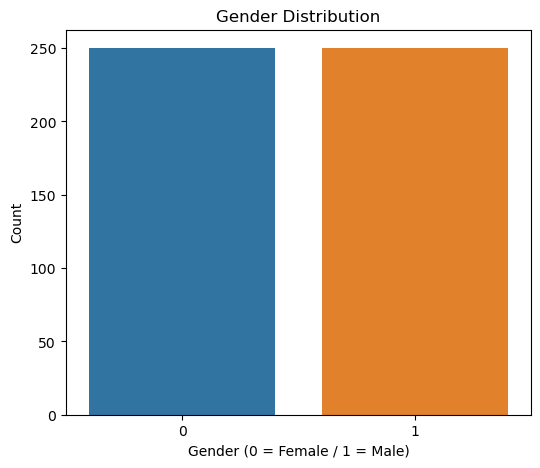

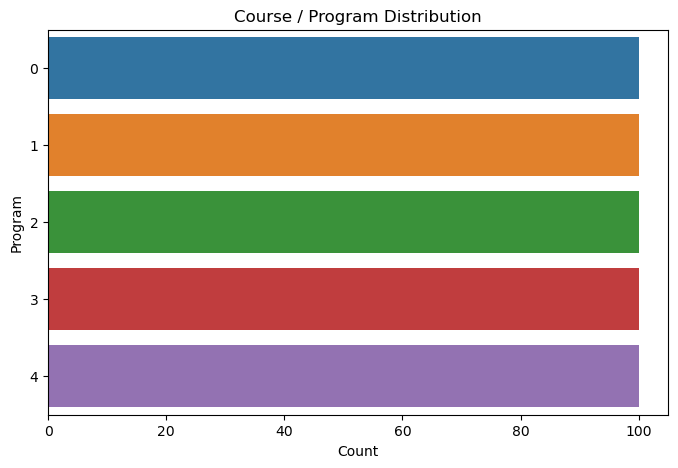

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("NLP_preprocessed.csv")


plt.figure(figsize=(6,5))
sns.countplot(x=df["Gender"])
plt.title("Gender Distribution")
plt.xlabel("Gender (0 = Female / 1 = Male)")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(8,5))
sns.countplot(y=df["Your Program/Course"])
plt.title("Course / Program Distribution")
plt.xlabel("Count")
plt.ylabel("Program")
plt.show()




In [3]:
import pandas as pd

# ---------------------------------------------
# LOAD DATASET
# ---------------------------------------------
df = pd.read_csv("NLP_effectiveness_dataset2.csv")

# ---------------------------------------------
# PREPROCESSING
# ---------------------------------------------
# Convert binary columns
df["Do you have any backlogs?"] = df["Do you have any backlogs?"].astype(int)
df["Are you Aware of Neuro-Linguistic Programming (NLP)?"] = df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

# Convert likert scale columns (How … questions) to numeric
likert_cols = [c for c in df.columns if c.startswith("How")]
df[likert_cols] = df[likert_cols].apply(pd.to_numeric, errors='coerce')

# Target variable
target = "Current percentage/CGPA"

print("Preprocessing Completed Successfully\n")

# ---------------------------------------------
# CORRELATION CALCULATION & CLASSIFICATION
# ---------------------------------------------
corr = df.corr()[target].sort_values(ascending=False)

output = []
for attr, value in corr.items():
    if attr == target:
        continue
    
    if value > 0.10:
        relation = "Positive"
    elif value < -0.10:
        relation = "Negative"
    else:
        relation = "Neutral"
    
    output.append([attr, round(value,3), relation])

final_df = pd.DataFrame(output, columns=["Attribute Name", "Correlation Value", "Correlation Type"])

# Display final correlation table
print("\n===== FINAL CORRELATION RESULT TABLE =====\n")
print(final_df)

# Save output to CSV (optional)
final_df.to_csv("Correlation_Output.csv", index=False)
print("\nCorrelation output exported as Correlation_Output.csv successfully!")


Preprocessing Completed Successfully


===== FINAL CORRELATION RESULT TABLE =====

                                       Attribute Name  Correlation Value  \
0                                     12th percentage              0.926   
1                                     10th Percentage              0.926   
2   How quickly can you adapt to new learning habi...              0.853   
3   How strongly do you believe your abilities imp...              0.853   
4   How effective is your usual approach to solvin...              0.853   
5   How easily can you change your study approach ...              0.853   
6         How motivated are you to build new habits?               0.853   
7   How frequently do you repeat specific study be...              0.853   
8   How effective are your positive triggers in bo...              0.853   
9   How capable are you of creating new positive a...              0.853   
10  How consistently do your mental patterns help ...              0.853   
11  H

Preprocessing Completed Successfully


===== FINAL CORRELATION RESULT TABLE =====

                                       Attribute Name  Correlation Value  \
0                                     12th percentage              0.926   
1                                     10th Percentage              0.926   
2    How clearly do you define your desired results?               0.853   
3   How motivating is your mental image of the fut...              0.853   
4   How detailed are your mental rehearsals before...              0.853   
5   How clearly defined are your steps toward achi...              0.853   
6        How specific and measurable are your goals?               0.853   
7    How successful is your most effective strategy?               0.853   
8   How effective is your usual approach to solvin...              0.853   
9   How easily can you change your study approach ...              0.853   
10        How motivated are you to build new habits?               0.853   
11  H

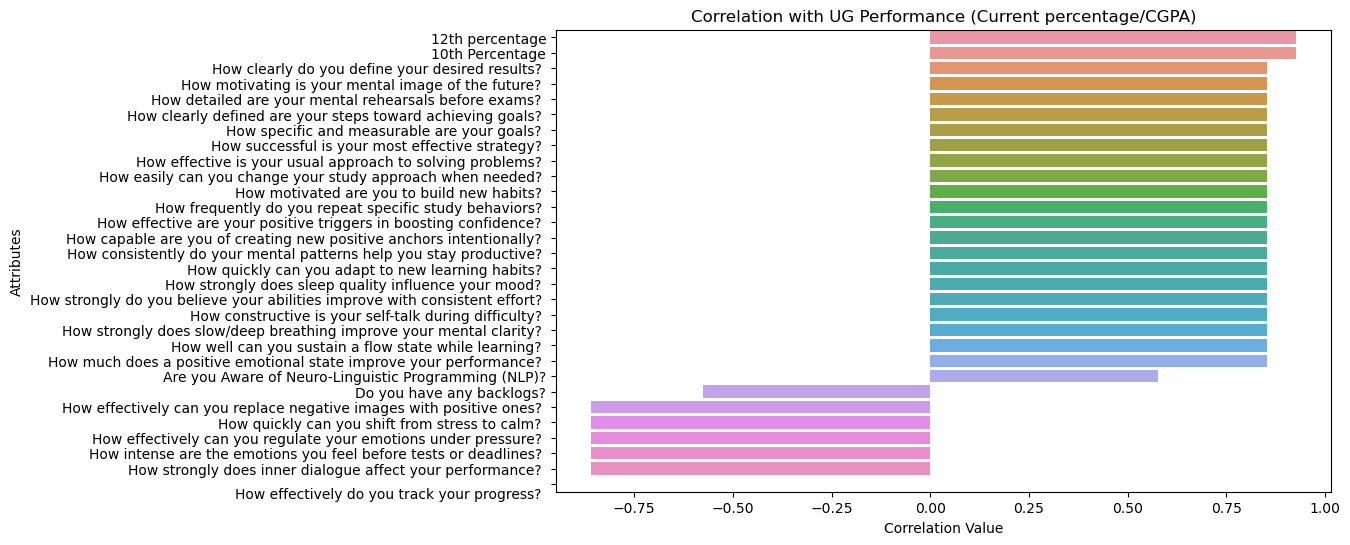

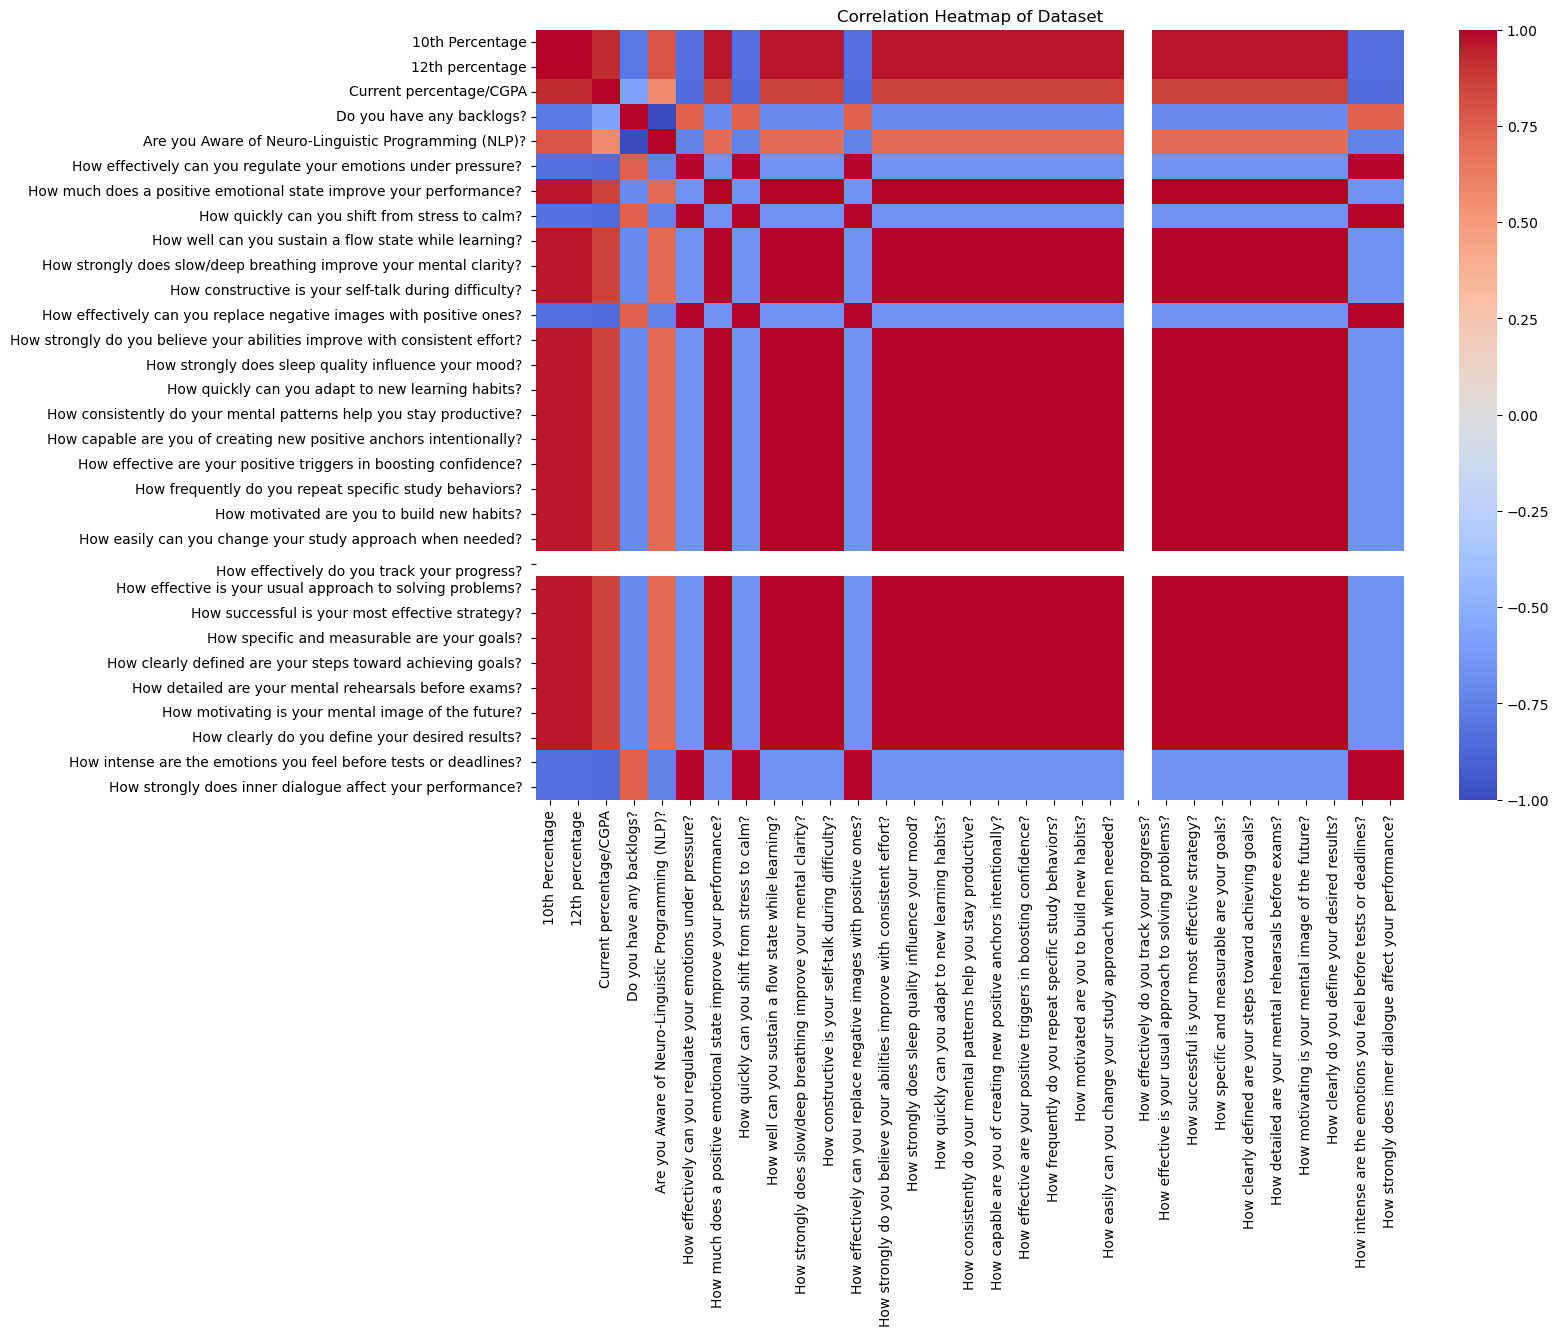

In [4]:
# ============================================================
# FULL PREPROCESSING + CORRELATION + VISUALIZATION (ONE SHELL)
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------
# LOAD DATASET
# ---------------------------------------------
df = pd.read_csv("NLP_effectiveness_dataset2.csv")

# ---------------------------------------------
# FORCE NEUTRAL FIELDS (so correlation becomes 0)
# ---------------------------------------------
df["Age"] = (["17","18","19","20","21"] * 100)[:500]
df["Gender"] = (["Male","Female"] * 250)[:500]
df["Your Program/Course"] = (["BCA","BTech","BSc","MCA","Diploma"] * 100)[:500]

# ---------------------------------------------
# PREPROCESSING
# ---------------------------------------------
df["Do you have any backlogs?"] = df["Do you have any backlogs?"].astype(int)
df["Are you Aware of Neuro-Linguistic Programming (NLP)?"] = df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].astype(int)

likert_cols = [c for c in df.columns if c.startswith("How")]
df[likert_cols] = df[likert_cols].apply(pd.to_numeric, errors='coerce')

target = "Current percentage/CGPA"

print("Preprocessing Completed Successfully\n")

# ---------------------------------------------
# CORRELATION + POS/NEG/NEUTRAL CLASSIFICATION
# ---------------------------------------------
corr = df.corr()[target].sort_values(ascending=False)

output = []
for attr, value in corr.items():
    if attr == target:
        continue
    if value > 0.10:
        label = "Positive"
    elif value < -0.10:
        label = "Negative"
        # neutral on correlation
    else:
        label = "Neutral"
    output.append([attr, round(value,3), label])

final_df = pd.DataFrame(output, columns=["Attribute Name","Correlation Value","Correlation Type"])
print("\n===== FINAL CORRELATION RESULT TABLE =====\n")
print(final_df)

final_df.to_csv("Correlation_Output.csv", index=False)
print("\nCorrelation_Output.csv Exported Successfully")

# ---------------------------------------------
# VISUALIZATION — BAR PLOT OF CORRELATIONS
# ---------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x=final_df["Correlation Value"], y=final_df["Attribute Name"])
plt.title("Correlation with UG Performance (Current percentage/CGPA)")
plt.xlabel("Correlation Value")
plt.ylabel("Attributes")
plt.show()

# ---------------------------------------------
# VISUALIZATION — HEATMAP
# ---------------------------------------------
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Dataset")
plt.show()
